In [1]:
#from pathlib import Path
import pandas as pd
import numpy as np
import h5py
import sys
import re
import matplotlib.pyplot as plt
import os
from contextlib import chdir
import scipy.fft as fft
import scipy.optimize as solve
import scipy.constants
#import NuRadioMC
#import NuRadioReco
import radiotools.atmosphere.models as refractiv
refractiv.default_model = 1
"""
Need to keep atm_model = 1 for compatibility with Kernelgenerator. 
"""
import math
import time
import tables
from Functions import *
from ExternalFunctions import *

In [6]:
RunMGMR("April2run2.hdf5")

Program folder = /home/rguz126/MasterThesis/VitalOrigineleCode/pyMGMR3D-main/program
Run folder     = /home/rguz126/MasterThesis/VitalOrigineleCode/pyMGMR3D-main/run
Input file     = /home/rguz126/MasterThesis/VitalOrigineleCode/pyMGMR3D-main/run/SIM000001.in
HDF5 output to = /home/rguz126/MasterThesis/VitalOrigineleCode/pyMGMR3D-main/run/SIM000001.hdf5
make: Nothing to be done for 'all'.
 starting
 LIBRARY=
    -4,  16, 17, 19, 20, 21, -15                                                 
  "data/data_275251207_cut.dat"                                                  
   start Initialize @ 18:10:55.680 -------------------------
 command=grid  args=   10.000000000000000      OutFilePrefix=<
 command====== args=   10.000000000000000      OutFilePrefix=<
   start    endgame @ 18:11:44.361 -------------------------
 ReducedChisq=   30.617291780754890     
HDF5 file created at: /home/rguz126/MasterThesis/VitalOrigineleCode/pyMGMR3D-main/run/SIM000001.hdf5
Stored 32 input parameters under '

In [2]:
xcoords,ycoords,distances,angles = GetcoordinatesfromVitalMGMR("April2run2.hdf5")
UniqueValues,counts = GetUniqueValuesWithWeights(distances)
FocalPointHeights = [0.1,  0.2, .500, 1.500, 2.500, 3.500, 4.500, 5.500, 7.000, 8.500, 10.000, 12., 14., 17., 20., -1.]
RunBeamForming(UniqueValues,counts,FocalPointHeights,45,"april2run2.hdf5")

Define MGMR system variables and PATH extensions
Program folder= /home/rguz126/MasterThesis/VitalOrigineleCode/pyMGMR3D-main/Beamforming/BeamformingRuns/../program
AntennaFunction= /Users/users/rguz126/LOFLI/AntenFunct/v2-
working directory= /home/rguz126/MasterThesis/VitalOrigineleCode/pyMGMR3D-main/Beamforming/BeamformingRuns
Program: BeamForm-GenerateKernel
Input from: Kernel-SKA.in
program run is: BeamForm-GenerateKernel with argument Kernel-SKA.in
executing command: '/home/rguz126/MasterThesis/VitalOrigineleCode/pyMGMR3D-main/Beamforming/BeamformingRuns/../program/BeamForm-GenerateKernel   <Kernel-SKA.in '
 Taking RS_0 =   0.0000000000000000     
   start Initialize @ 18: 6:37.709 -------------------------
 Work folder= "SKx/Coarse"
 Zenith angle =  0.78539816339744828     
   start Initialize @ 18: 6:37.711 -------------------------
   start Generate Kernel @20000. @ 18: 6:37.751 -------------------------
   start Generate Kernel @  100. @ 18: 6:37.751 -------------------------
 

**Rest of notebook is still work in progress to implement the final step of combining the data with the kernel.**

In [ ]:
def CalculatePx(DataBeamedData,Kernel,LargestCalcDistance,OutputFile,DatabeamDataStep,Freqmin = 48*1e6,Freqmax = 300*1e6):
    """ 
    Work in progres
    Databeamstep in seconds, not currently working properly. 
    """
    DatabeamedDatahdf5 = h5py.File(DataBeamedData)
    hdf5Kernel = h5py.File(Kernel)
    LenDataBeamData = 0 
    for item in DatabeamedDatahdf5:
        LenDataBeamData = len(np.array(DatabeamedDatahdf5[item]))
        break 
    distances = np.array([],dtype = "int")
    for item in hdf5Kernel:
        distances = np.append(distances,int(item))
    distances = np.sort(distances)
    PKR = CalculatePKR(Kernel,LargestCalcDistance)
    SpecificKernel = hdf5Kernel[str(LargestCalcDistance)]
    tmin = SpecificKernel.attrs["tmin"]*1e-9
    tmax = SpecificKernel.attrs["tmax"]*1e-9
    ymin = SpecificKernel.attrs["DcMin"]
    ymax = SpecificKernel.attrs["DcMax"]
    ny = int(np.round(SpecificKernel.attrs["nDc"]))
    nt = int(np.round(SpecificKernel.attrs["nt"]))
    nts = np.linspace(tmin,tmax,nt)
    Dn = (ymax-ymin)/(ny-1)
    PxOutput = np.zeros([len(distances)])
    PxRollIters = np.zeros([len(distances)])
    Totaltime = DatabeamDataStep*LenDataBeamData
    Newnts = np.linspace(-Totaltime/2,Totaltime/2,LenDataBeamData)
    InterpolPKR = BlockFreqFilter(np.interp(Newnts,nts,PKR,left = 0, right = 0),DatabeamDataStep,Freqmin,Freqmax)
    #InterpolPKR = np.interp(Newnts,nts,PKR,left = 0, right = 0)
    fig, ax = plt.subplots()          
    ax.plot(Newnts,InterpolPKR)
    txt="Interpolated pulse kernel response function with a 48-300 Mhz filter"
    plt.xlabel("time [s]")
    plt.ylabel("value of Kernel [no units]")
    plt.figtext(0.5, -0.1, txt, wrap=True, horizontalalignment='center', fontsize=12)
    plt.show()                 
    print(distances)
    for distanceiter in range(len(distances)):
        #fig, ax = plt.subplots()          
        #ax.plot(np.array(DatabeamedDatahdf5[str(distances[distanceiter])]))
        #plt.show()       
        for Rolliteration in range(len(np.array(DatabeamedDatahdf5[str(distances[distanceiter])]))):
            if Rolliteration != 880:
                continue
            NewPKR = np.roll(InterpolPKR,Rolliteration)
            PxTotal = np.dot(np.array(DatabeamedDatahdf5[str(distances[distanceiter])]),NewPKR).sum(axis = 0)
            if PxOutput[distanceiter] < PxTotal:
                PxOutput[distanceiter] = PxTotal
                PxRollIters[distanceiter] = Rolliteration
    return PxOutput,PxRollIters

In [418]:
KernelInput = h5py.File("CircleEvery10mAntennaWeight1With50Antennas.hdf5")

In [411]:
Kernelhdf5 = h5py.File("CircleEvery10mAntennaWeight1With50Antennas.hdf5")
distances = np.array([],dtype = "int")
for item in Kernelhdf5:
    distances = np.append(distances,int(item))
distances = np.sort(distances)
k = DatabeamingBeamforming("CSVBeamformed.hdf5",distances)

In [32]:
Kernelhdf5 = h5py.File("March25Run1Kernel.hdf5")
distances = np.array([],dtype = "int")
for item in Kernelhdf5:
    distances = np.append(distances,int(item))
distances = np.sort(distances)
k = Databeaming("March25Run1.hdf5","March25Run1Beamformed.hdf5",distances)

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_112257/3144015642.py:4: SyntaxWarning: invalid escape sequence '\s'
  Rawdata2 = pd.read_csv('./SKAINIT/SKA/Crs-x-BeamPwr-tt.dat', sep="\s+", engine='python', comment='!', header=None)


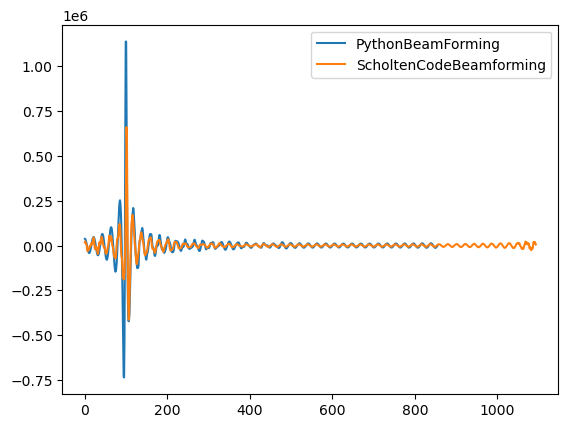

In [44]:
distances = np.array([2020])
k = DatabeamingBeamforming("March25Run1BeamformedScholten5.hdf5",distances)
ScholtenDataformat = h5py.File("March25Run1BeamformedScholten5.hdf5")
Rawdata2 = pd.read_csv('./SKAINIT/SKA/Crs-x-BeamPwr-tt.dat', sep="\s+", engine='python', comment='!', header=None)
Rawdata2Array = np.array(Rawdata2)
plt.plot(np.array(ScholtenDataformat["2020"])[238:],label = "PythonBeamForming")
plt.plot(Rawdata2Array[:,1],label = "ScholtenCodeBeamforming")
plt.legend()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13715/1662433103.py:4: SyntaxWarning: invalid escape sequence '\s'
  Rawdata2 = pd.read_csv('./SKAINIT/SKA/Crs-x-BeamPwr-tt.dat', sep="\s+", engine='python', comment='!', header=None)


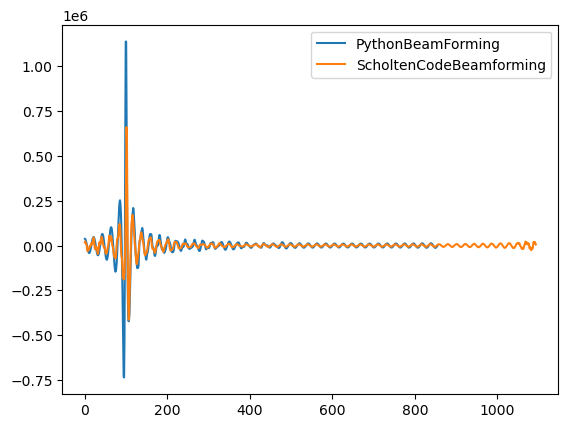

In [367]:
distances = np.array([2020])
k = DatabeamingScholten("March25Run1BeamformedScholten6.hdf5",distances)
ScholtenDataformat = h5py.File("March25Run1BeamformedScholten6.hdf5")
Rawdata2 = pd.read_csv('./SKAINIT/SKA/Crs-x-BeamPwr-tt.dat', sep="\s+", engine='python', comment='!', header=None)
Rawdata2Array = np.array(Rawdata2)
plt.plot(np.array(ScholtenDataformat["2020"])[238:],label = "PythonBeamForming")
plt.plot(Rawdata2Array[:,1],label = "ScholtenCodeBeamforming")
plt.legend()

In [412]:
def CalculateWeightingFunction2(kernelhdf5,LargestCalcDistance,WeightingFunctionhdf5):
    hdf5WeightingFile = h5py.File(WeightingFunctionhdf5,"w")
    Attributestemp = ["DcMin","DcMax","nDc"]
    Kernel = h5py.File(kernelhdf5)
    PKR = CalculatePKR(kernelhdf5,LargestCalcDistance)
    DbCount = len(Kernel)
    for Db in Kernel:
        tempdata = np.dot(Kernel[Db],PKR)
        hdf5WeightingFile.create_dataset(Db,data = tempdata)
        for attribute in Attributestemp:
            hdf5WeightingFile[Db].attrs[attribute] = Kernel[Db].attrs[attribute]
    hdf5WeightingFile.close()

In [413]:
def CalculateWeightingFunction(kernelhdf5,LargestCalcDistance,WeightingFunctionhdf5):
    CurrentDirectory = os.getcwd()
    Kernel = h5py.File(kernelhdf5)
    hdf5WeightingFile = h5py.File(WeightingFunctionhdf5,"w")
    Attributestemp = ["DcMin","DcMax","nDc"]
    PKR = CalculatePKR(Kernel,LargestCalcDistance)
    DbCount = len(Kernel)
    for Db in Kernel:
        tempdata = np.dot(Kernel[Db],PKR)
        hdf5WeightingFile.create_dataset(Db,data = tempdata)
        for attribute in Attributestemp:
            hdf5WeightingFile[Db].attrs[attribute] = Kernel[Db].attrs[attribute]
    hdf5WeightingFile.close()

In [34]:
MGMRhdf5 = "March25Run1.hdf5"
Kernelhdf5 = "March25Run1Kernel.hdf5"
LargestCalcDistance = 17000
#WeightingFunctionhdf5 = "TestWeightingNewAndImrpoved.hdf5"
DataBeamedDatahdf5 = "March25Run1Beamformed.hdf5"
ConversionToNanoS = 1000
#CalculateWeightingFunction(Kernelhdf5,17000,"CSVWeightingFunction.hdf5")
WeightingFunctionhdf5 = "March25Run1WeightingFunction.hdf5"

In [36]:
AtmosphereModel = refractiv.Atmosphere(model = 1, curved = False)
MGMRData = h5py.File(MGMRhdf5)
ZenithShowerAngle = MGMRData["inputs"].attrs["Zen_sh"]
MGMRtmin = 0
MGMRtmax = 0
MGMRnt = 0
MGMRTimes = np.array([])
for antenna in MGMRData["observers"]:
    MGMRAntennafile = MGMRData["observers/"+antenna]
    MGMRtmin = MGMRAntennafile[0,0]*ConversionToNanoS
    MGMRtmax = MGMRAntennafile[-1,0]*ConversionToNanoS
    MGMRnt = int(len(MGMRAntennafile[:,0]))
    MGMRTimes = MGMRAntennafile[:,0]*ConversionToNanoS
    break
WeightingFunction = h5py.File(WeightingFunctionhdf5)
Kernel = h5py.File(Kernelhdf5)
DatabeamedData = h5py.File(DataBeamedDatahdf5)
PKR = CalculatePKR(Kernelhdf5,LargestCalcDistance)
distances = np.array([],dtype = "int")
for item in Kernel:
    distances = np.append(distances,int(item))
distances = np.sort(distances)
Kerneltmin = Kernel[str(distances[0])].attrs["tmin"]
Kerneltmax = Kernel[str(distances[0])].attrs["tmax"]
Kernelnt = int(np.round(Kernel[str(distances[0])].attrs["nt"]))
Kerneltimes = np.linspace(Kerneltmin,Kerneltmax,Kernelnt)
DatabeamDatainterpolFull = np.zeros([len(distances),len(Kerneltimes)])
Px = np.zeros([len(distances)])
FullDcs = np.array([])
FullDcsatmos = np.array([])

In [37]:
AtmosphereModel = refractiv.Atmosphere(model = 1, curved = False)
#CalculateWeightingFunction(Kernelhdf5,LargestCalcDistance,WeightingFunctionhdf5)
MGMRData = h5py.File(MGMRhdf5)
ZenithShowerAngle = MGMRData["inputs"].attrs["Zen_sh"]
MGMRtmin = 0
MGMRtmax = 0
MGMRnt = 0
MGMRTimes = np.array([])
for antenna in MGMRData["observers"]:
    MGMRAntennafile = MGMRData["observers/"+antenna]
    MGMRtmin = MGMRAntennafile[0,0]*1000
    MGMRtmax = MGMRAntennafile[-1,0]*1000
    MGMRnt = int(len(MGMRAntennafile[:,0]))
    MGMRTimes = MGMRAntennafile[:,0]*1000
    break
WeightingFunction = h5py.File(WeightingFunctionhdf5)
Kernel = h5py.File(Kernelhdf5)
DatabeamedData = h5py.File(DataBeamedDatahdf5)
PKR = CalculatePKR(Kernelhdf5,LargestCalcDistance)
distances = np.array([],dtype = "int")
for item in Kernel:
        distances = np.append(distances,int(item))
distances = np.sort(distances)
Kerneltmin = Kernel[str(distances[0])].attrs["tmin"]
Kerneltmax = Kernel[str(distances[0])].attrs["tmax"]
Kernelnt = int(np.round(Kernel[str(distances[0])].attrs["nt"]))
Kerneltimes = np.linspace(Kerneltmin,Kerneltmax,Kernelnt)
FullDcsatmos = {}
for distanceiter in range(len(distances)):
    DatabeamDatainterpolFull[distanceiter] = np.interp(Kerneltimes,MGMRTimes,DatabeamedData[str(distances[distanceiter])],left = 0, right = 0)
    Dcs = np.linspace(WeightingFunction[str(distances[distanceiter])].attrs["DcMin"],WeightingFunction[str(distances[distanceiter])].attrs["DcMax"],int(WeightingFunction[str(distances[distanceiter])].attrs["nDc"]))
    Dcsatmos = np.zeros(len(Dcs))
    for iteration in range(len(Dcs)):
        DcAtmos = AtmosphereModel.get_atmosphere(ZenithShowerAngle,h_low = Dcs[iteration])
        Dcsatmos[iteration] = DcAtmos
    FullDcsatmos[str(int(distances[distanceiter]))] = Dcsatmos
    Px[distanceiter] = np.dot(DatabeamDatainterpolFull[distanceiter],PKR)
def CalculateChiSquare2(Fitparams):
    Variation = 0
    for qklqsdfml in range(len(distances[0:10])):
        Guess = np.dot(WeightingFunction[str(int(distances[qklqsdfml]))],GaisserHillasCurrentProfile(FullDcsatmos[str(int(distances[qklqsdfml]))],Fitparams[0],Fitparams[1],Fitparams[2],Fitparams[3]))
        Variation += np.sum(np.power(Guess-Px[qklqsdfml],2))
    return Variation
def calcchisquare3(fitparam):
    return CalculateChiSquare2([fitparam[0],0.25,250,fitparam[1]])
#result = solve.minimize(CalculateChiSquare2,Fitparams)
#print(result)

In [96]:
WeightingFunction = h5py.File(WeightingFunctionhdf5)

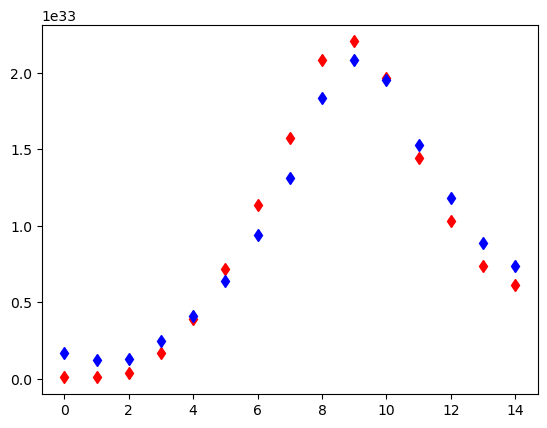

In [38]:
R,L = LambaXoToRL(82.15,100.58,696.05)
Fitparams = np.array([4217212*1e24*4,R,L,696.05])
Guesses = np.zeros(len(distances))
for iterat in range(len(distances)):
    Guess = np.dot(WeightingFunction[str(int(distances[iterat]))],GaisserHillasCurrentProfile(FullDcsatmos[str(int(distances[iterat]))],Fitparams[0],Fitparams[1],Fitparams[2],Fitparams[3]))
    Guesses[iterat] = Guess
plt.plot(Px,"rd")
plt.plot(Guesses,"bd")

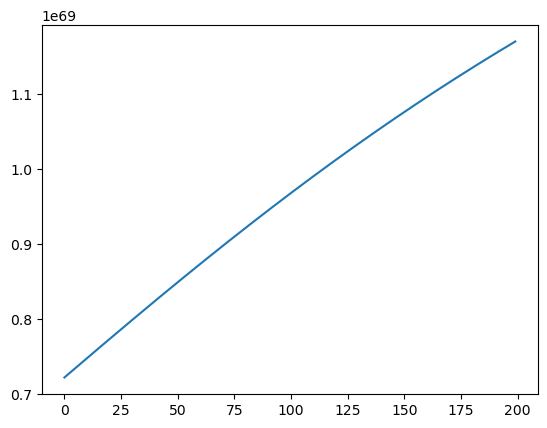

In [39]:
R,L = LambaXoToRL(82.15,100.58,696.05)
Fitparams = np.array([4217212*1e24*4,R,L,696.05])
Chisquares = np.zeros(200)
Endresult = np.arange(-100,100)
FitfinalParam = Fitparams[3]
for iteration in range(len(Endresult)):
    NewXmax = FitfinalParam+Endresult[iteration]
    R,L = LambaXoToRL(82.15,100.58,NewXmax)
    Fitparams = np.array([44217212*1e24*4,R,L,NewXmax])
    Chisquare = CalculateChiSquare2(Fitparams)
    Chisquares[iteration] = Chisquare
plt.plot(Chisquares)

In [40]:
InitParams = np.array([82.15,100.58,896.05])
R,L = LambaXoToRL(InitParams[0],InitParams[1],InitParams[2])
Fitparams = np.array([421721200000000000000000*1.5,R,L,896.05])
Chisquares = np.zeros(200)
Endresult = np.arange(-10,10,0.1)
FitfinalParam = Fitparams[3]
for iteration in range(len(Endresult)):
    New1max = InitParams[0]+Endresult[iteration]
    R,L = LambaXoToRL(New1max,InitParams[1],InitParams[2])
    Fitparams = np.array([421721200000000000000000*1.5,R,L,InitParams[2]])
    Chisquare = CalculateChiSquare2(Fitparams)
    Chisquares[iteration] = Chisquare

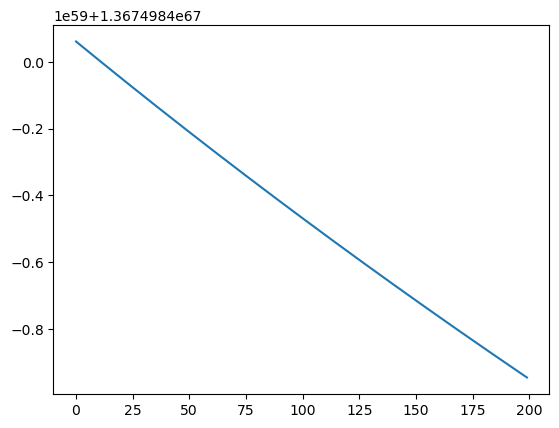

In [41]:
plt.plot(Chisquares)

In [ ]:
DatabeamedData[:,0

In [101]:
k = h5py.File("FinalTestv3SingleBump.hdf5")

In [106]:
k["observers/pos_010_045"].attrs["columns"]

array([b't_us', b'Re_Ex', b'Re_Ey', b'Im_Ex', b'Im_Ey'], dtype='|S5')

In [114]:
Kernel = h5py.File("KernelFinaltestv3.hdf5")
PKR = CalculatePKR("KernelFinaltestv3.hdf5",17000)
    DbCount = len(Kernel)
    for Db in Kernel:
        tempdata = np.dot(Kernel[Db],PKR)
        hdf5WeightingFile.create_dataset(Db,data = tempdata)
        for attribute in Attributestemp:
            hdf5WeightingFile[Db].attrs[attribute] = Kernel[Db].attrs[attribute]
    hdf5WeightingFile.close()